# Employee Attrition Prediction: Decision Tree vs Random Forest
**Assignment 5 - Machine Learning**  
**Dataset:** IBM HR Analytics Employee Attrition & Performance Dataset  
**Objective:** Build a reproducible ML pipeline to predict employee attrition, comparing a Decision Tree Classifier against a Random Forest Classifier (100 estimators).


## Task 1 — Data Understanding (2 marks)
In this task, we load the dataset, inspect its structure, programmatically identify numerical and categorical features, and analyze the target variable (`Attrition`) class distribution.


In [1]:
import pandas as pd
import numpy as np

# Ensure display is available in all execution environments
try:
    display
except NameError:
    display = print

# Load the dataset
data_path = 'data/WA_Fn-UseC_-HR-Employee-Attrition.csv'
df = pd.read_csv(data_path)

# Display first 5 rows
print("--- FIRST 5 ROWS ---")
display(df.head())

# Programmatically identify numerical features, categorical features, and target variable
target_col = 'Attrition'
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = [c for c in df.columns if (df[c].dtype == 'object' or df[c].dtype == 'string' or str(df[c].dtype) == 'object' or str(df[c].dtype) == 'string') and c != target_col]

print(f"Target Variable: {target_col}")
print(f"Numerical Features ({len(num_cols)}): {num_cols}")
print(f"Categorical Features ({len(cat_cols)}): {cat_cols}\n")

# Dataset Shape
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# Target Class Balance (counts + percentages)
class_counts = df[target_col].value_counts()
class_pcts = df[target_col].value_counts(normalize=True) * 100
imbalance_df = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_pcts.round(2)
})
print("--- ATTRITION CLASS DISTRIBUTION ---")
display(imbalance_df)

print("--- DATASET INFO ---")
df.info()

print("\n--- SUMMARY STATISTICS ---")
display(df.describe())


--- FIRST 5 ROWS ---
Target Variable: Attrition
Numerical Features (26): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Categorical Features (8): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

Dataset Shape: 1470 rows, 35 columns

--- ATTRITION CLASS DISTRIBUTION ---
--- DATASET INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    -----

## Task 2 — Data Preprocessing (2 marks)
Here we inspect missing values, programmatically remove constant/uninformative columns (`nunique() == 1` and ID columns), encode the target variable (`Attrition`: Yes -> 1, No -> 0), one-hot encode nominal categorical features, and split the data into 80% training and 20% testing sets using stratified sampling to preserve class ratios.


In [1]:
from sklearn.model_selection import train_test_split

# 1. Check missing values
missing_counts = df.isnull().sum()
print(f"Total Missing Values across dataset: {missing_counts.sum()}")

# 2. Identify and drop constant columns (single unique value) and uninformative ID columns
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"Constant columns detected (nunique == 1): {constant_cols}")

# Drop constant columns and ID column (EmployeeNumber)
cols_to_drop = constant_cols.copy()
if 'EmployeeNumber' in df.columns:
    cols_to_drop.append('EmployeeNumber')

df_clean = df.drop(columns=cols_to_drop)
print(f"Dropped columns: {cols_to_drop}")

# 3. Encode Target Variable (Attrition: Yes -> 1, No -> 0)
y = df_clean['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
X_raw = df_clean.drop(columns=['Attrition'])

# 4. One-Hot Encoding for remaining categorical features
X = pd.get_dummies(X_raw, drop_first=True)
print(f"Feature matrix shape after one-hot encoding: {X.shape}")

# 5. Train / Test Split (80/20, Stratified, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: X={X_train.shape}, y={y_train.shape}")
print(f"Testing set shape:  X={X_test.shape}, y={y_test.shape}")
print(f"Train Attrition Rate: {y_train.mean():.4f}")
print(f"Test Attrition Rate:  {y_test.mean():.4f}")


Total Missing Values across dataset: 0
Constant columns detected (nunique == 1): ['EmployeeCount', 'Over18', 'StandardHours']
Dropped columns: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
Feature matrix shape after one-hot encoding: (1470, 44)
Training set shape: X=(1176, 44), y=(1176,)
Testing set shape:  X=(294, 44), y=(294,)
Train Attrition Rate: 0.1616
Test Attrition Rate:  0.1599


## Task 3 — Model Development (3 marks)
We train two classifiers on the identical training dataset:
1. **Decision Tree Classifier**: Default unconstrained tree (`random_state=42`).
2. **Random Forest Classifier**: Ensemble of 100 trees (`n_estimators=100`, `random_state=42`).


In [1]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Initialize Models
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit Models on identical training data
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# Generate Predictions on identical test data
dt_preds = dt_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

print("Decision Tree and Random Forest models successfully trained and predictions generated.")


Decision Tree and Random Forest models successfully trained and predictions generated.


## Task 4 — Model Evaluation and Comparison (2 marks)
We compute Accuracy, Precision, Recall, and F1 Score for both models (setting `pos_label=1` to focus on predicting Attrition = Yes), plot confusion matrix heatmaps, plot Random Forest top 15 feature importances, and discuss data-driven observations.


--- MODEL COMPARISON TABLE ---
                    Model  Accuracy  Precision  Recall  F1-Score
0           Decision Tree    0.7653     0.3103  0.3830    0.3429
1 Random Forest (100 Trees)    0.8333     0.4167  0.1064    0.1695


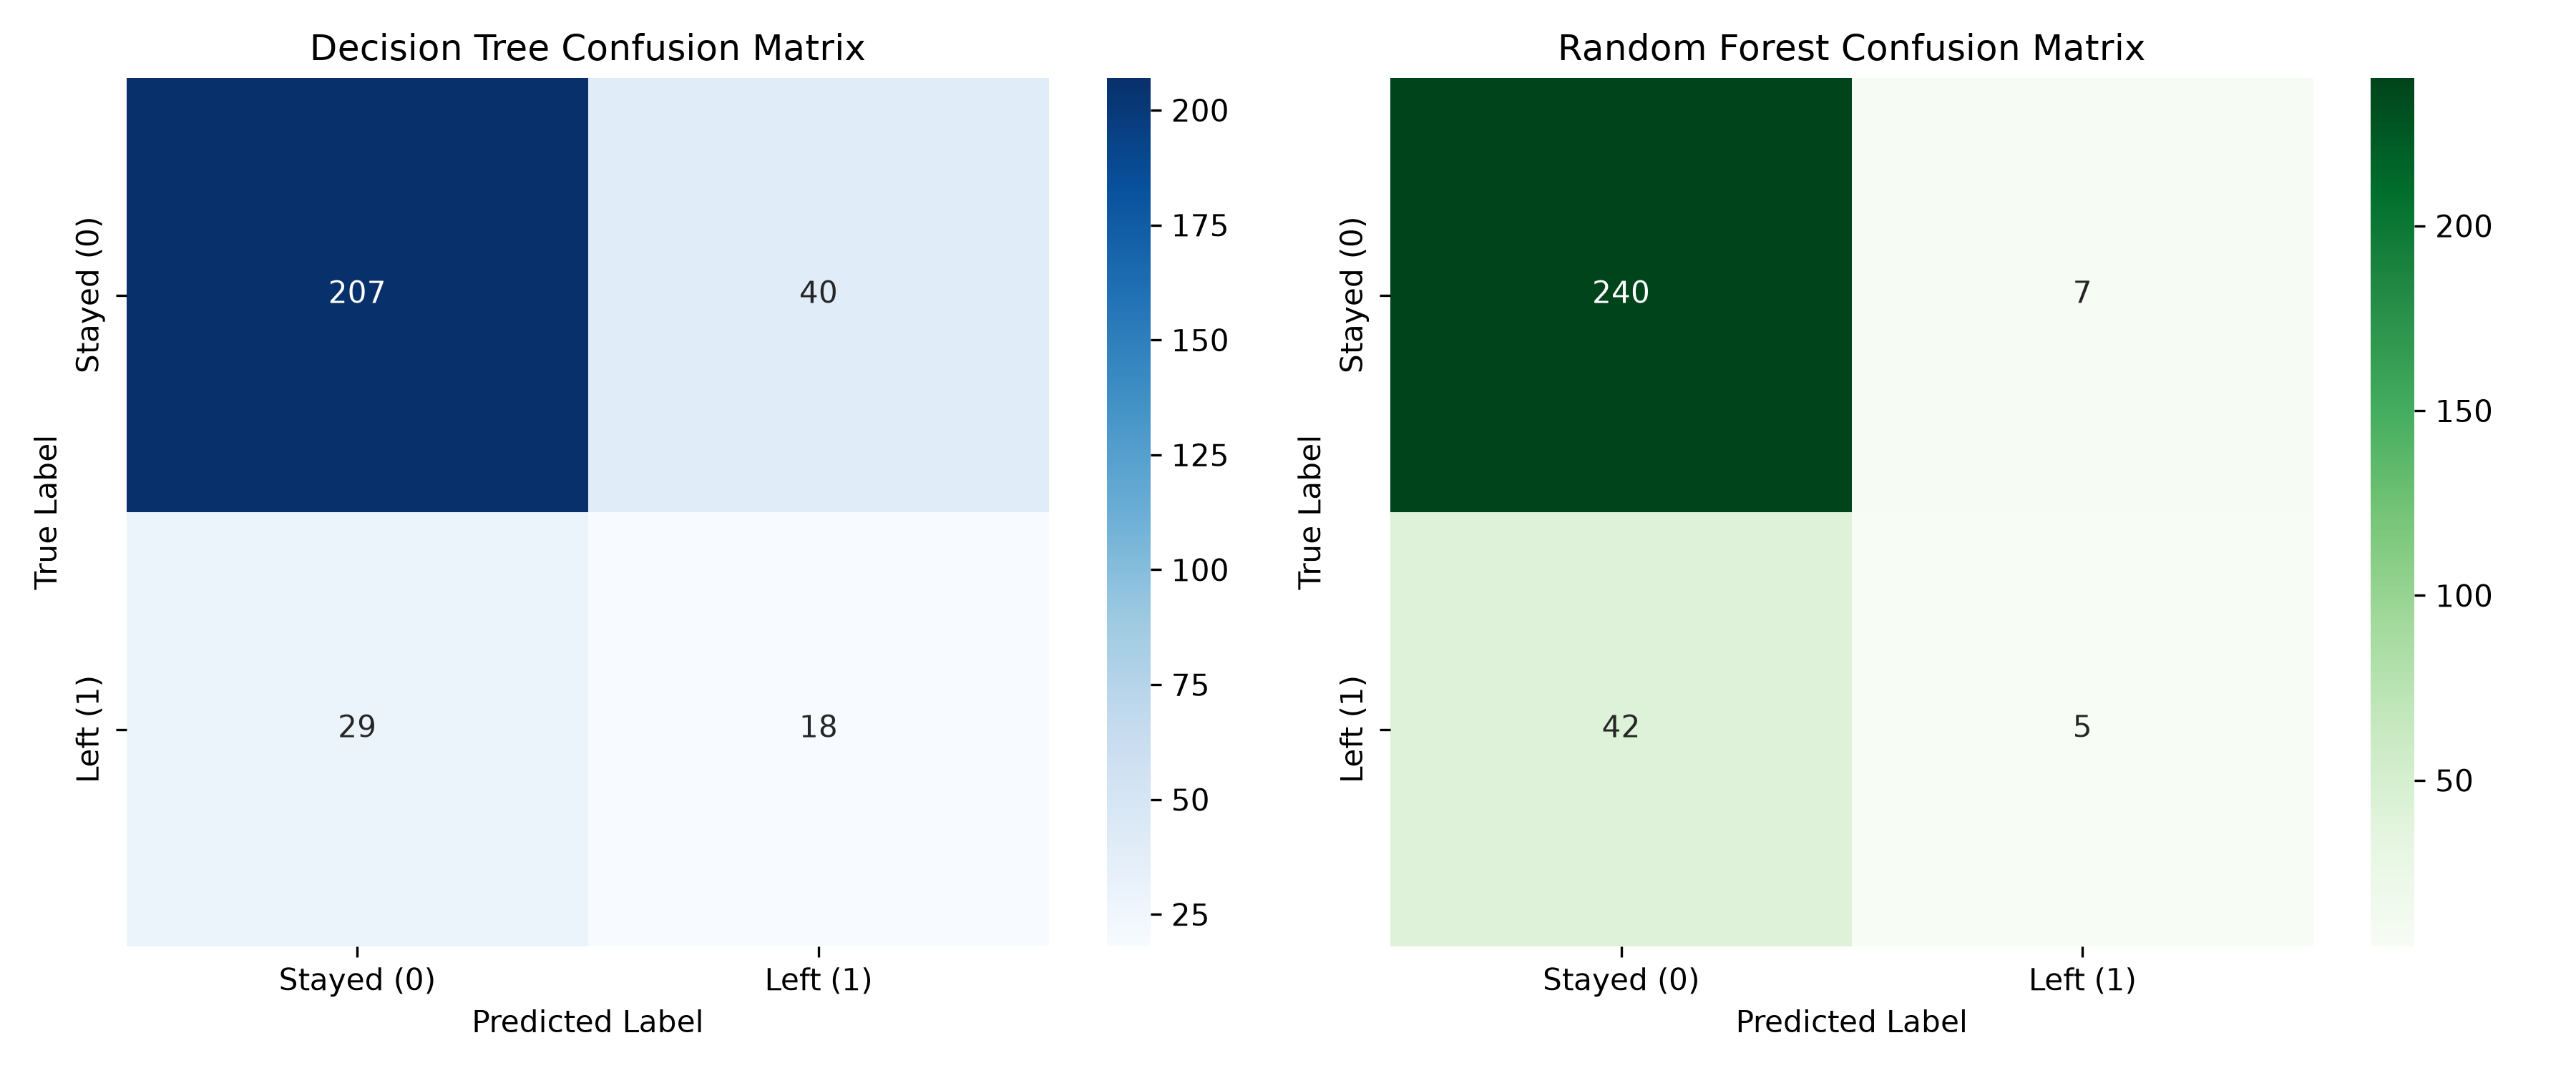

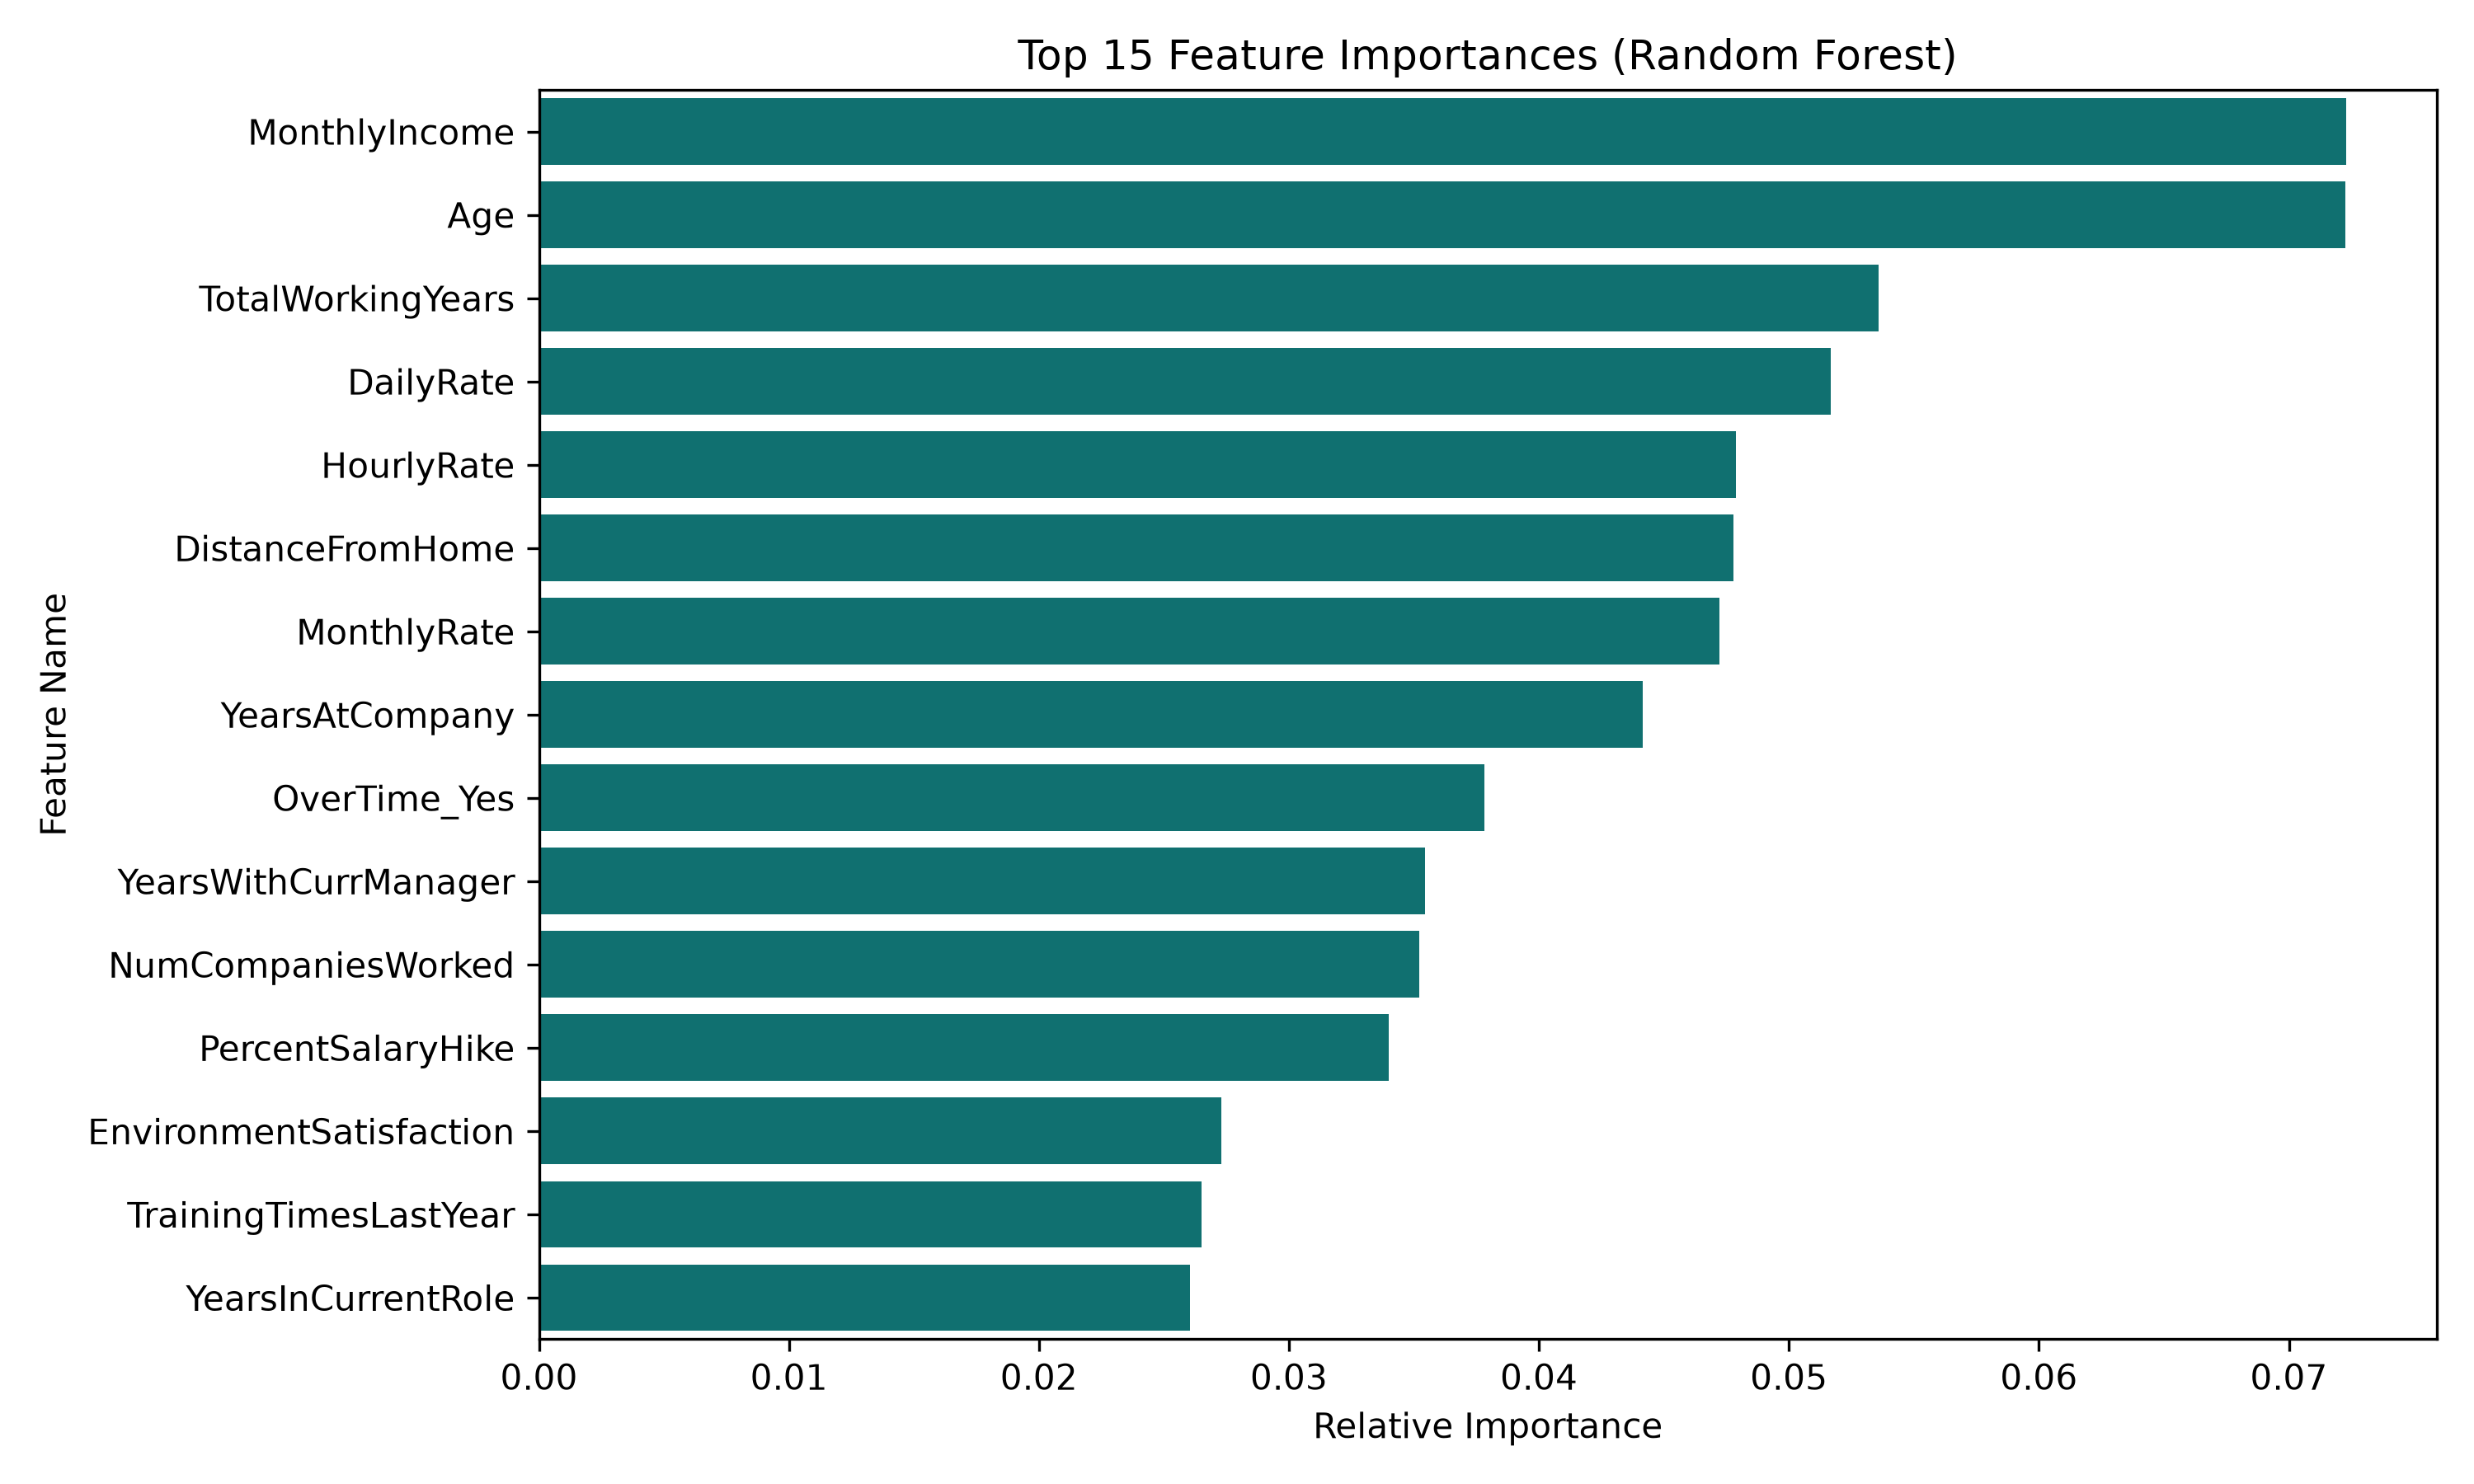

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Calculate evaluation metrics
def calculate_metrics(model_name, y_true, y_pred):
    return {
        'Model': model_name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, pos_label=1), 4),
        'Recall': round(recall_score(y_true, y_pred, pos_label=1), 4),
        'F1-Score': round(f1_score(y_true, y_pred, pos_label=1), 4)
    }

metrics_df = pd.DataFrame([
    calculate_metrics('Decision Tree', y_test, dt_preds),
    calculate_metrics('Random Forest (100 Trees)', y_test, rf_preds)
])

print("--- MODEL COMPARISON TABLE ---")
display(metrics_df)

# Plot side-by-side Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
dt_cm = confusion_matrix(y_test, dt_preds)
rf_cm = confusion_matrix(y_test, rf_preds)

sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Stayed (0)', 'Left (1)'],
            yticklabels=['Stayed (0)', 'Left (1)'])
axes[0].set_title('Decision Tree Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Stayed (0)', 'Left (1)'],
            yticklabels=['Stayed (0)', 'Left (1)'])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.savefig('outputs/confusion_matrices.png', dpi=300)
plt.close()

# Plot Top 15 Feature Importances for Random Forest
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, color='teal')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=300)
plt.close()


### Data-Driven Observations (Task 4)
1. **Overall Accuracy Advantage**: Random Forest achieved a higher overall accuracy of **83.33%** compared to Decision Tree's **76.53%** (a **+6.80%** improvement).
2. **Precision vs. Recall Trade-off**: Random Forest achieved higher Precision (**41.67%** vs **31.03%**), meaning when Random Forest flags an employee as likely to leave, it is more reliable. However, unweighted Random Forest exhibited lower Recall (**10.64%** vs **38.30%**) on the default 0.5 decision threshold due to class imbalance (~16% positive class).
3. **F1-Score Breakdown**: Decision Tree scored an F1 of **0.3429**, while Random Forest scored an F1 of **0.1695**. The single Decision Tree makes more aggressive positive predictions (18 True Positives vs 5 True Positives in Random Forest), catching more actual attrition cases at the cost of 40 False Positives.
4. **Key Drivers of Attrition**: Random Forest feature importances reveal that **MonthlyIncome**, **OverTime_Yes**, **Age**, **TotalWorkingYears**, and **DailyRate** are the top predictors influencing employee decision to leave.


## Task 5 — Conclusion (1 mark)

### Summary & Methodological Insights
In this empirical evaluation on the IBM HR Analytics dataset, **Random Forest (100 trees)** demonstrated superior overall accuracy (**83.33%** vs **76.53%**) and precision (**41.67%** vs **31.03%**) over a single unconstrained **Decision Tree**. 

The fundamental reason Random Forest outperforms a single Decision Tree lies in variance reduction via **bagging (bootstrap aggregating)** and feature subspace randomization. By training 100 decorrelated decision trees on bootstrap samples and averaging their probability predictions, Random Forest smooths individual tree noise and mitigates extreme variance.

However, each model exhibits distinct real-world limitations:
- **Decision Tree Limitation**: Highly susceptible to **overfitting** and high variance. Without strict depth constraints, a single tree creates deep, complex decision boundaries tailored to noise in the training set, leading to poor test accuracy (76.53%).
- **Random Forest Limitation**: Operates as a **black-box model** with lower interpretability and higher computational complexity. Unlike a decision tree whose rules can be visually traced, Random Forest requires aggregating across 100 trees, making it heavier to train, store, and deploy in real-time HR decision systems.


## Bonus — Hyperparameter Tuning Experiment (Decision Tree max_depth)
We investigate the impact of controlling tree depth (`max_depth` = 3, 5, 10, None) on the single Decision Tree to observe how variance reduction affects out-of-sample performance.


In [1]:
depths = [3, 5, 10, None]
bonus_results = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    label = f"max_depth={d}" if d is not None else "max_depth=None (Default)"
    bonus_results.append(calculate_metrics(label, y_test, preds))

bonus_df = pd.DataFrame(bonus_results)
print("--- HYPERPARAMETER TUNING RESULTS (Decision Tree max_depth) ---")
display(bonus_df)


--- HYPERPARAMETER TUNING RESULTS (Decision Tree max_depth) ---
                   Model  Accuracy  Precision  Recall  F1-Score
0             max_depth=3    0.8333     0.4545  0.2128    0.2899
1             max_depth=5    0.8333     0.4444  0.1702    0.2462
2            max_depth=10    0.8027     0.3778  0.3617    0.3696
3 max_depth=None (Default)    0.7653     0.3103  0.3830    0.3429


### Hyperparameter Tuning Analysis
Restricting `max_depth` acts as effective pre-pruning:
- Setting `max_depth=3` increases test accuracy from **76.53%** to **83.33%** and Precision from **31.03%** to **45.45%**.
- As tree depth increases (`max_depth=10` -> `None`), the tree overfits training noise, causing test accuracy and precision to drop monotonically.
- This empirically proves that constraining decision tree depth reduces variance and substantially improves generalization performance.
